# Module 5 Homework: Chapter 6 Exercises

## Ryan Waterman
## 8/8/2025

## Chapter Notes

1. Prediction Accuracy in Linear Models for data sets where the relationship between response and predictor are approximately linear depends on the ratio between the number of observations (n) and predictors (p). High n:p have lower variance and perform better on test data. Low n:p can have higher variability in the least squares fit, leading to poor predictions on novel data. If p>n, there is no longer a least squares coefficient estimate, and the model will have extremely high variance. These issues can be mitigated by shrinking p for data sets with low n:p.
2. Best Subset Selection:
     - Compares the R<sup>2</sup> of the null model to the R<sup>2</sup> of all models with k predictors, up to p. The best of model for each k is *M*<sub>*k*</sub>, and then all *M*<sub>*k*</sub> models are compared using prediction error on a validation set, *C*<sub>*p*</sub>, AIC, BIC, Adjusted R<sup>2</sup>, or Cross-Validation.
3. Forward Stepwise Selection:
    - Let *M*<sub>*0*</sub> denote the null model, which contains no predictors.
    - For k = 0 , . . . , p −1:
        1. Consider all p − k models that augment the predictors in *M*<sub>*k*</sub> with one additional predictor.
        2. Choose the best among these p − k models, and call it *M*<sub>*k+1*</sub>. Here best is defined as having smallest RSS or highest R<sup>2</sup>.
    - Select a single best model from among *M*<sub>*0*</sub>, . . . , *M*<sub>*p*</sub> using the prediction error on a validation set, *C*<sub>*p*</sub>, (AIC), BIC, adjusted R<sup>2</sup>, or use the cross-validation method.
4. Backward Stepwise Selection:
    - Let *M*<sub>*p*</sub> denote the full model, which contains all p predictors.
    - For k = p, p −1, . . . , 1:
        1. Consider all k models that contain all but one of the predictors in *M*<sub>*k*</sub>, for a total of k −1 predictors.
        2. Choose the best among these k models, and call it *M*<sub>*k-1*</sub>. Here best is defined as having smallest RSS or highest R<sup>2</sup>.
    3. Select a single best model from among M0, . . . , Mp using the prediction error on a validation set, *C*<sub>*p*</sub>, (AIC), BIC, or adjusted R<sup>2</sup>. Or use the cross-validation method.
5. Training set MSE is generally an under-estimate of test MSE.
6. For a fitted least squares model with *d* predictors, the *C*<sub>*p*</sub> estimate of test MSE is computed using:

    ![img](c_p.png)

    where σ_hat<sup>2</sup> is an estimate of the variance of the error ε associated with each response measurement. Typically σ_hat<sup>2</sup> is estimated using the full model containing all predictors.

7. AIC is described by the equation, below:

    ![img](aic.png)

    For least squares models, *C*<sub>*p*</sub> and AIC are proportional.
 
8. BIC is described by the equation, below:

    ![img](bic.png)

    BIC generally places a heavier penalty on models with many variables.



# Problem 9

In this exercise, we will predict the number of applications received using the other variables in the College data set.

In [2289]:
import pandas as pd
import statsmodels.api as sm
import numpy as np
from random import randint, seed
from ISLP import load_data
import matplotlib.pyplot as plt
import warnings
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score
from ISLP.models import ModelSpec as MS
from functools import partial
from ISLP.models import Stepwise, sklearn_selected, sklearn_selection_path

warnings.filterwarnings('ignore')

In [2290]:
college = load_data('College')

### Dataset Information

Statistics for a large number of US Colleges from the 1995 issue of US News and World Report.

Private: A factor with levels No and Yes indicating private or public university

Apps: Number of applications received

Accept: Number of applications accepted

Enroll: Number of new students enrolled

Top10perc: Pct. new students from top 10% of H.S. class

Top25perc: Pct. new students from top 25% of H.S. class

F.Undergrad: Number of fulltime undergraduates

P.Undergrad: Number of parttime undergraduates

Outstate: Out-of-state tuition

Room.Board: Room and board costs

Books: Estimated book costs

Personal: Estimated personal spending

PhD: Pct. of faculty with Ph.D.’s

Terminal: Pct. of faculty with terminal degree

S.F.Ratio: Student/faculty ratio

perc.alumni: Pct. alumni who donate

Expend: Instructional expenditure per student

Grad.Rate: Graduation rate

In [2291]:
college.head(5)

,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
0,Yes,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
1,Yes,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
2,Yes,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
3,Yes,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
4,Yes,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15


## Part A

Split the data set into a training set and a test set.

In [2292]:
def split_data(data, train_perc:int):
    seed(42)
    train_indices = []
    test_indices = []

    for i in data.index.values:
        rand_num = randint(1,100)
        if rand_num <= train_perc:
            train_indices.append(i)
        else:
            test_indices.append(i)

    training_data = data.iloc[train_indices]
    test_data = data.iloc[test_indices]
    
    return training_data, test_data

In [2293]:
qauntitative = set(college.describe().columns)
categorical = set(college.columns) - qauntitative

cat_counts = {}

for var in categorical:
    cat_counts[var] = [[cat for cat in college[var].unique()], [i for i in range(len(college[var].unique()))]]


In [2294]:
for key, val in cat_counts.items():
    college[key].replace(val[0], val[1], inplace = True)

In [2295]:
college['Private'] = college['Private'].cat.codes

In [2296]:
college.dtypes

Private           int8
Apps             int64
Accept           int64
Enroll           int64
Top10perc        int64
Top25perc        int64
F.Undergrad      int64
P.Undergrad      int64
Outstate         int64
Room.Board       int64
Books            int64
Personal         int64
PhD              int64
Terminal         int64
S.F.Ratio      float64
perc.alumni      int64
Expend           int64
Grad.Rate        int64
dtype: object

In [2297]:
college.head(5)

,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
0,1,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
1,1,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
2,1,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
3,1,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
4,1,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15


In [2298]:
training_data, test_data = split_data(college, 80)

print(len(training_data), len(test_data))

613 164


## Part B

Fit a linear model using least squares on the training set, and report the test error obtained.

#### **Fitting Least Squares Model and Determining Test Error**

**Estimating the Test Error will be done using *C*<sub>*p*</sub>**

In [2299]:
def nCp(sigma2, estimator, X, Y):
    "Negative Cp statistic is used because sklearn maximizes scores."
    n, p = X.shape
    Yhat = estimator.predict(X)
    RSS = np.sum((Y - Yhat)**2)
    return -(RSS + 2 * p * sigma2) / n


**Determine σ_hat<sup>2</sup> of the training data set with all predictors.**

In [2300]:
design = MS(training_data.columns.drop('Apps')).fit(training_data)

Y = np.array(training_data['Apps'])
X = design.transform(training_data) 

m_0 = sm.OLS(Y, X).fit()
sigma2 = m_0.scale
sigma2

np.float64(1153867.9470437404)

**Freeze the nCp scorer and σ_hat<sup>2</sup> variable.**

In [2301]:
neg_Cp = partial(nCp, sigma2)

**Utilize a forward stepwise selection algorithm to determine the best model.**

In [2302]:
strategy = Stepwise.first_peak(design,
                                direction='forward',
                                max_terms=len(design.terms))

In [2303]:
training_MSE = sklearn_selected(sm.OLS,
                                    strategy)
training_MSE.fit(training_data, Y)
training_MSE.selected_state_

('Accept',
 'Books',
 'Enroll',
 'Expend',
 'F.Undergrad',
 'Grad.Rate',
 'Outstate',
 'P.Undergrad',
 'Personal',
 'PhD',
 'Private',
 'Room.Board',
 'S.F.Ratio',
 'Terminal',
 'Top10perc',
 'Top25perc',
 'perc.alumni')

In [2304]:
training_Cp = sklearn_selected(sm.OLS,
                                strategy,
                                scoring=neg_Cp)
training_Cp.fit(training_data, Y)
training_Cp.selected_state_

('Accept',
 'Enroll',
 'Expend',
 'Grad.Rate',
 'Outstate',
 'Personal',
 'PhD',
 'Private',
 'Room.Board',
 'Top10perc',
 'Top25perc')

**Now that the variable selection has been complete, train a new model on the training subset and test it.**

In [2305]:
best_var_X = training_data[list(training_Cp.selected_state_)]
Y = np.array(training_data['Apps'])

best_var_model = sm.OLS(Y, best_var_X).fit()

**Calculate MSE based on each model's predictions using the mean_squared_error function.**

In [2306]:
test_y = test_data['Apps']
test_X = test_data[list(training_Cp.selected_state_)]

In [2307]:
test_X.columns

Index(['Accept', 'Enroll', 'Expend', 'Grad.Rate', 'Outstate', 'Personal',
       'PhD', 'Private', 'Room.Board', 'Top10perc', 'Top25perc'],
      dtype='object')

In [2308]:
from sklearn.metrics import mean_squared_error

In [2309]:
test_y_pred = best_var_model.predict(test_X)
train_y_pred = best_var_model.predict(best_var_X)

train_mse = mean_squared_error(y_true=Y, y_pred=train_y_pred)
test_mse = mean_squared_error(y_true=test_y, y_pred=test_y_pred)
print(f'Train MSE: {train_mse}\tTest MSE: {test_mse}')

Train MSE: 1126154.5678536464	Test MSE: 897911.5847397848


In [2310]:
model_results = {}
def save_model_results(model_name, train_mse, test_mse):
    model_results[model_name] = {'train_mse':train_mse,
                                 'test_mse':test_mse}

In [2311]:
save_model_results('Best Variable Selection', train_mse, test_mse)

**Train MSE is greater than test MSE, which is typically an indicator of an issue with the model or the data, as the model is predicting on the test data more accurately than it is predicting on the training data. It is possible that there are outliers in the training split of the data that do not exist in the test split, making the test data easier to predict than the training data.**

## Part C

Fit a ridge regression model on the training set, with λ chosen by cross-validation. Report the test error obtained.

In [2312]:
import sklearn.linear_model as skl
from sklearn.pipeline import Pipeline
import sklearn.model_selection as skm
from sklearn.preprocessing import StandardScaler

In [2313]:
X = training_data.drop('Apps', axis = 1)
Y = training_data['Apps']

Xs = X - np.array(X.mean(0))[None,:]
X_scale = X.std(0)
Xs = Xs / np.array(X_scale)[None,:]
lambdas = 10**np.linspace(8, -2, 100) / Y.std()

soln_array = skl.ElasticNet.path(Xs,
                                Y,
                                l1_ratio=0.,
                                alphas=lambdas)[1]

In [2314]:
soln_path = pd.DataFrame(soln_array.T,
                        columns=X.columns,
                        index=lambdas)
soln_path.index.name = 'lambda'
soln_path

,Private,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
lambda,,,,,,,,,,,,,,,,,
24961.400767,-0.067491,0.150888,0.135312,0.058744,0.060762,0.128951,0.068058,0.010713,0.027426,0.023778,0.027424,0.064190,0.060030,0.010358,-0.011308,0.043788,0.026898
19781.483227,-0.085160,0.190391,0.170737,0.074123,0.076669,0.162710,0.085875,0.013518,0.034606,0.030002,0.034603,0.080993,0.075744,0.013070,-0.014269,0.055252,0.033939
15676.487161,-0.107454,0.240235,0.215434,0.093526,0.096738,0.205305,0.108354,0.017056,0.043665,0.037856,0.043661,0.102194,0.095570,0.016491,-0.018005,0.069716,0.042824
12423.347982,-0.135580,0.303124,0.271828,0.118007,0.122059,0.259047,0.136716,0.021520,0.055094,0.047765,0.055089,0.128941,0.120584,0.020808,-0.022720,0.087965,0.054034
9845.290816,-0.171066,0.382470,0.342978,0.148892,0.154004,0.326851,0.172498,0.027152,0.069515,0.060265,0.069506,0.162685,0.152140,0.026255,-0.028668,0.110989,0.068178
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0.000006,-211.438339,4047.566964,-816.419972,995.127628,-362.936690,227.300030,10.973349,-406.943907,165.501874,-9.480149,68.198349,-128.061869,-37.940253,32.311089,-15.355385,437.919168,184.609620
0.000005,-211.437145,4047.613629,-816.491943,995.147663,-362.953010,227.330123,10.972086,-406.951857,165.499280,-9.480824,68.199656,-128.063759,-37.938159,32.310502,-15.351449,437.918411,184.609554
0.000004,-211.436199,4047.650613,-816.548983,995.163542,-362.965943,227.353974,10.971084,-406.958157,165.497225,-9.481359,68.200692,-128.065257,-37.936499,32.310036,-15.348330,437.917811,184.609501


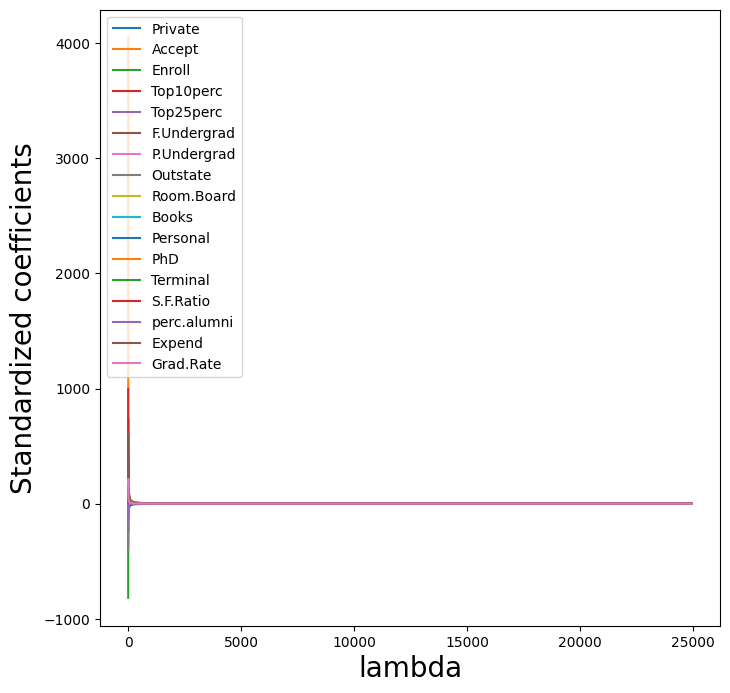

In [2315]:
path_fig, ax = plt.subplots(figsize=(8,8))
soln_path.plot(ax=ax, legend=False)
ax.set_xlabel('lambda', fontsize=20)
ax.set_ylabel('Standardized coefficients', fontsize=20) 
ax.legend(loc='upper left');

**Given the output, above, it is advantageous to -log transform lambda.**

In [2316]:
soln_path_n_log = pd.DataFrame(soln_array.T,
                        columns=X.columns,
                        index=-np.log(lambdas))
soln_path_n_log.index.name = 'negative log(lambda)'
soln_path_n_log.iloc[35:45]

,Private,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
negative log(lambda),,,,,,,,,,,,,,,,,
-1.984634,-138.140032,355.885756,299.251296,119.351117,117.527012,279.620829,132.752694,20.912627,60.403213,45.744606,49.677638,112.507677,102.824805,21.923118,-32.307839,95.202658,61.605177
-1.752049,-156.846375,418.010897,346.145008,136.121442,132.276870,321.917391,148.817040,23.976662,70.272998,51.249847,54.616143,123.321339,111.991466,24.762601,-38.789207,110.370512,72.206461
-1.519465,-175.287449,486.564795,395.498519,153.222146,146.429119,365.726598,163.612206,27.222722,80.978348,56.357133,58.616749,132.038416,118.912649,27.414903,-46.102740,126.676569,83.872724
-1.286881,-192.710624,561.360039,446.207299,170.245706,159.325440,409.811475,176.118133,30.592895,92.433374,60.752826,61.261848,137.776665,122.720846,29.707658,-54.208302,143.976383,96.520924
-1.054296,-208.394278,642.204559,497.010533,186.832402,170.337112,452.789757,185.322812,33.988947,104.528246,64.136669,62.201502,139.785605,122.683351,31.486273,-63.030148,162.124129,110.007752
-0.821712,-221.739695,728.969977,546.553189,202.725109,178.928931,493.210355,190.336968,37.250392,117.125691,66.257786,61.220421,137.564717,118.320351,32.644137,-72.456951,180.982899,124.114411
-0.589127,-232.346689,821.641309,593.433016,217.811499,184.707749,529.617208,190.506690,40.132587,130.054590,66.946745,58.292497,130.954427,109.497680,33.148033,-82.338991,200.425667,138.534691
-0.356543,-240.056361,920.340157,636.226723,232.147269,187.446140,560.593445,185.507919,42.291593,143.103571,66.137886,53.608276,120.177533,96.472342,33.051159,-92.480702,220.327067,152.874059
-0.123959,-244.953197,1025.323123,673.501710,245.959180,187.077790,584.791048,175.410078,43.282375,156.018583,63.877997,47.565670,105.818537,79.878106,32.488798,-102.629945,240.549566,166.667055


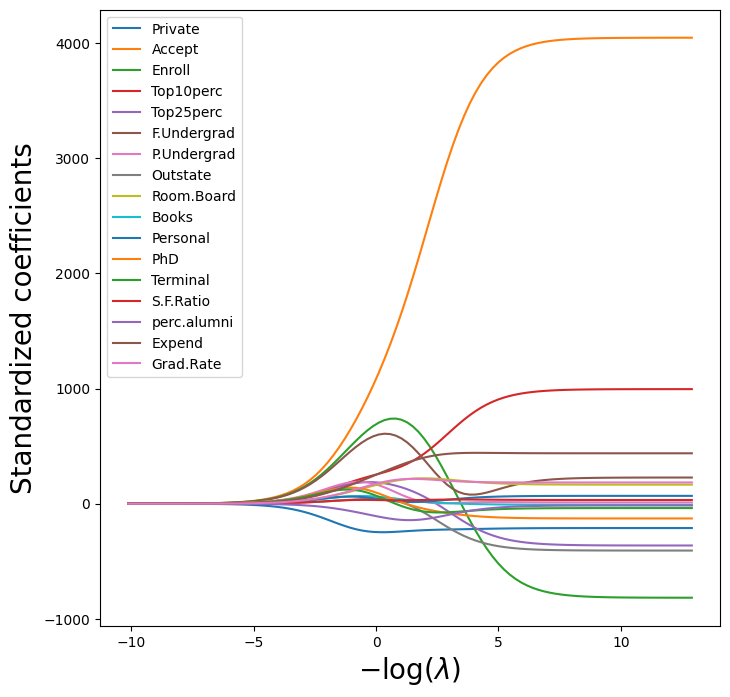

In [2317]:
path_fig, ax = plt.subplots(figsize=(8,8))
soln_path_n_log.plot(ax=ax, legend=False)
ax.set_xlabel('$-\log(\lambda)$', fontsize=20)
ax.set_ylabel('Standardized coefficients', fontsize=20) 
ax.legend(loc='upper left');

**I want to see what the minimum MSE is across all lambdas. See the code block, below:**

In [2318]:
mse_scores = {}

for i, lam in enumerate(lambdas): 
    ridge = skl.ElasticNet(alpha=lam, l1_ratio=0)
    scaler = StandardScaler(with_mean=True, with_std=True)
    pipe = Pipeline(steps=[('scaler', scaler), ( 'ridge', ridge)]) 
    pipe.fit(X, Y)

    validation = skm.ShuffleSplit(n_splits=1,
                test_size=0.8,
                random_state=0)

    results = skm.cross_validate(ridge,
                                X,
                                Y,
                                scoring='neg_mean_squared_error',
                                cv=validation)
    mse_scores[-results['test_score'][0]] = i

print(f'Lowest MSE lambda: {lambdas[mse_scores[min(mse_scores.keys())]]}\nIndex: {mse_scores[min(mse_scores.keys())]}\nMSE: {min(mse_scores.keys())}')

Lowest MSE lambda: 2.4961400767106194e-06
Index: 99
MSE: 1800681.4768716716


**As expected, the MSE shrinks proportionally to lambda, as the bias-variance trade-off shifts in the favor of bias, i.e. overfitting. A lambda of nearly 0 reduces the model to an OLS model. The book suggests a GridSearchCV for selection of lambda.** 

In [2319]:
param_grid = {'ridge__alpha': lambdas} 

grid = skm.GridSearchCV(pipe,
                        param_grid,
                        cv=validation,
                        scoring='neg_mean_squared_error')

grid.fit(X, Y)
grid.best_params_['ridge__alpha']
grid.best_estimator_

,steps,"[('scaler', ...), ('ridge', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,alpha,np.float64(2....767106194e-06)
,l1_ratio,0
,fit_intercept,True
,precompute,False


**This approach selected the same lambda parameter as my approach. I am wiling to bet the implementation is the same. Let's try again with k-fold cross validation.**

In [2320]:
K = 10 
kfold = skm.KFold(K,
                random_state=0,
                shuffle=True)

In [2321]:
grid = skm.GridSearchCV(pipe,
                        param_grid,
                        cv=kfold,
                        scoring='neg_mean_squared_error')
grid.fit(X, Y)
grid.best_params_['ridge__alpha']
grid.best_estimator_

,steps,"[('scaler', ...), ('ridge', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,alpha,np.float64(2....767106194e-06)
,l1_ratio,0
,fit_intercept,True
,precompute,False


**Again, the same lambda parameter was selected. Plotting MSE against -log($-\log(\lambda)$) will provide a bit more insight into the relationship between the two.**

Text(0, 0.5, 'Cross-validated MSE')

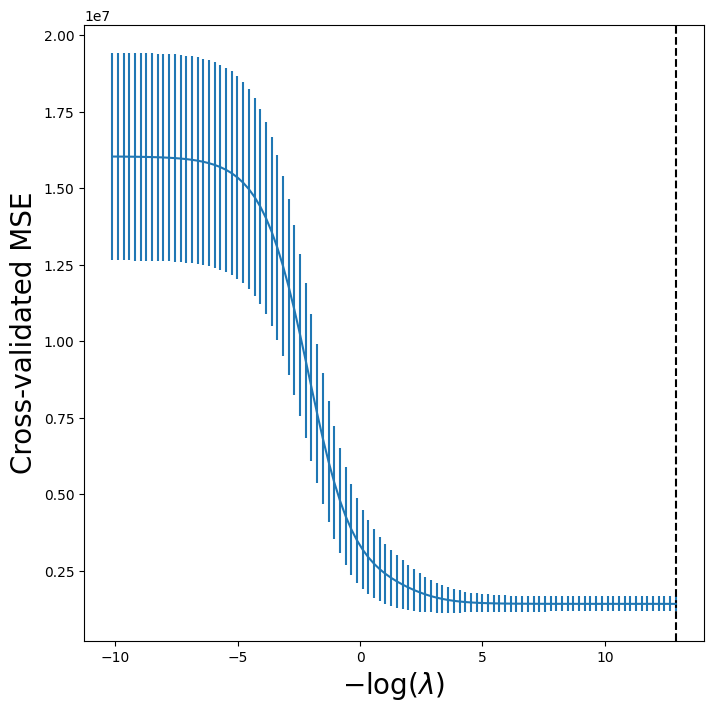

In [2322]:
ridge_fig, ax = plt.subplots(figsize=(8,8))
ax.errorbar(-np.log(lambdas),
            -grid.cv_results_['mean_test_score'],
            yerr=grid.cv_results_['std_test_score'] / np.sqrt(K)) 

ax.axvline(-np.log(lambdas[mse_scores[min(mse_scores.keys())]]), c='k', ls= '--')
ax.set_xlabel('$-\log(\lambda)$', fontsize=20) 
ax.set_ylabel('Cross-validated MSE', fontsize=20)

**Perhaps I made a mistake in my approach, but cross validation with negative MSE scoring does not seem like an effective method for selecting $-\log(\lambda)$. In each case, cross validation selected for a lambda value that minimized MSE, which drives lambda to 0. A zero-lambda ridge regression model reduces to an OLS model, therefore the cross validation methods used are not finding a lambda value that provides an optimal set of model coefficients to prevent overfitting. The Test MSE is calculated, below:**

#### **UPDATE:** 

**After experimenting with the training/test split seed, it is evident that this specific result is caused by chance due to the randomly selected training data. With a different seed, I was able to achieve an optimal lamda value at index 50, with a non-zero lambda.**

In [2323]:
test_X = test_data.drop('Apps', axis = 1)
test_y = test_data['Apps']

In [2324]:
ridge = skl.ElasticNet(alpha=lambdas[mse_scores[min(mse_scores.keys())]], l1_ratio=0)
scaler = StandardScaler(with_mean=True, with_std=True)
pipe = Pipeline(steps=[('scaler', scaler), ( 'ridge', ridge)]) 
pipe.fit(X, Y)

test_y_pred = pipe.predict(test_X)
train_y_pred = pipe.predict(X)

train_mse = mean_squared_error(y_true=Y, y_pred=train_y_pred)
test_mse = mean_squared_error(y_true=test_y, y_pred=test_y_pred)
print(f'Train MSE: {train_mse}\tTest MSE: {test_mse}')

Train MSE: 1119986.0184515722	Test MSE: 878225.8931979352


In [2325]:
save_model_results('Ridge Regression', train_mse, test_mse)

**The test MSE is lower than the training MSE, which is suspicious. As I commented on before, I think there may be an issue in my approach, but I haven't been able to find it. Alternatively, it is possible that there are outliers in the training split of the data that do not exist in the test split, making the test data easier to predict than the training data.**

## Part D

Fit a lasso model on the training set, with λ chosen by cross-validation. Report the test error obtained, along with the number of non-zero coefficient estimates.

In [2326]:
lassoCV = skl.ElasticNetCV(n_alphas=100,
                            l1_ratio=1,
                            cv=kfold)
pipeCV = Pipeline(steps=[('scaler', scaler), 
('lasso', lassoCV)]) 
pipeCV.fit(X, Y)
tuned_lasso = pipeCV.named_steps['lasso']
tuned_lasso.alpha_

np.float64(12.345000574483455)

In [2327]:
lambdas, soln_array = skl.Lasso.path(Xs,
                                    Y,
                                    l1_ratio=1,
                                    n_alphas=100)[:2]

soln_path = pd.DataFrame(soln_array.T,
                            columns=X.columns,
                            index=-np.log(lambdas))

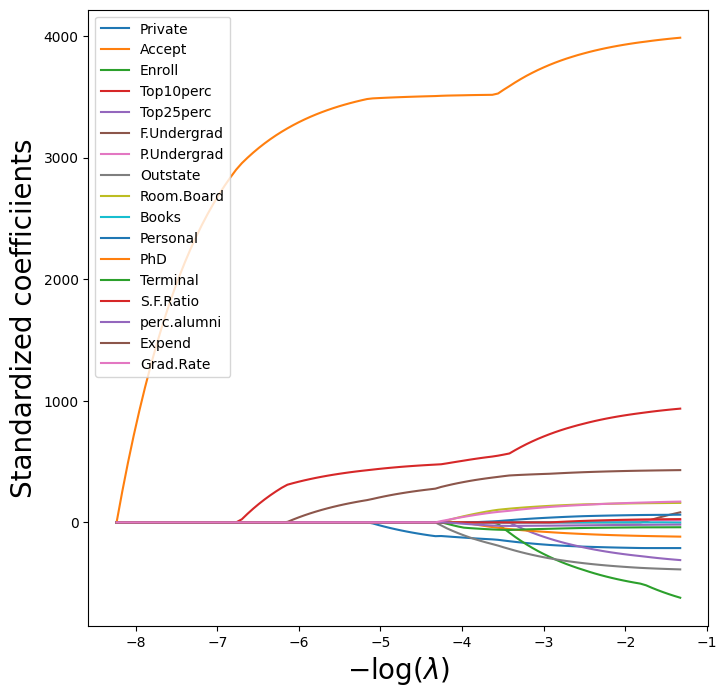

In [2328]:
path_fig, ax = plt.subplots(figsize=(8,8))
soln_path.plot(ax=ax, legend=False)
ax.legend(loc='upper left')
ax.set_xlabel('$-\log(\lambda)$', fontsize=20) 
ax.set_ylabel('Standardized coefficiients', fontsize=20);

In [2329]:
np.min(tuned_lasso.mse_path_.mean(1))

np.float64(1420362.2686680623)

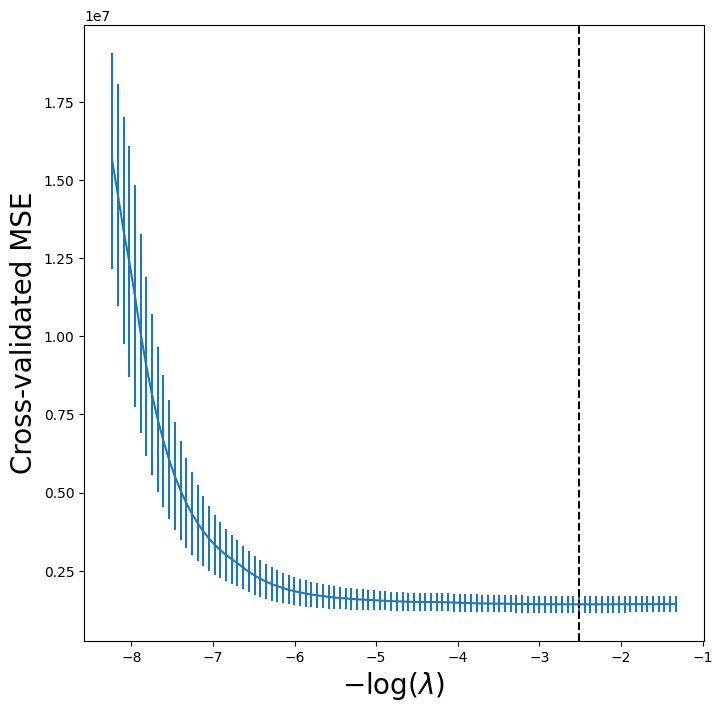

In [2330]:
lassoCV_fig, ax = plt.subplots(figsize=(8,8))

ax.errorbar(-np.log(tuned_lasso.alphas_),
            tuned_lasso.mse_path_.mean(1),
            yerr=tuned_lasso.mse_path_.std(1) / np.sqrt(K))

ax.axvline(-np.log(tuned_lasso.alpha_), c='k', ls= '--')
ax.set_xlabel('$-\log(\lambda)$', fontsize=20) 
ax.set_ylabel('Cross-validated MSE', fontsize=20); 

In [2331]:
tuned_lasso.coef_

array([-1.99307396e+02,  3.85324159e+03, -3.89993535e+02,  8.10186279e+02,
       -2.05101458e+02,  0.00000000e+00,  1.66276116e-01, -3.35264825e+02,
        1.47878161e+02, -0.00000000e+00,  5.09355042e+01, -9.56028888e+01,
       -4.60971679e+01,  1.21264667e+01, -2.45111386e+01,  4.12384064e+02,
        1.43433432e+02])

**The number of non-zero coefficients is 15. Two of the coefficients in the selected dataset went to zero.**

In [2332]:
test_y_pred = pipeCV.predict(test_X)
train_y_pred = pipeCV.predict(X)

train_mse = mean_squared_error(y_true=Y, y_pred=train_y_pred)
test_mse = mean_squared_error(y_true=test_y, y_pred=test_y_pred)
print(f'Train MSE: {train_mse}\tTest MSE: {test_mse}')

Train MSE: 1134925.6778885475	Test MSE: 859698.6031244679


In [2333]:
save_model_results('Lasso', train_mse, test_mse)

**As commented on before, a lower Test MSE than Train MSE is an indicator of an issue with the model or the data, as the model should not predict on the test data more accurately than the training data.**

## Part E

Fit a PCR model on the training set, with M chosen by cross-validation. Report the test error obtained, along with the value of M selected by cross-validation.

In [2334]:
from sklearn.decomposition import PCA

In [2335]:
pca = PCA(n_components=2)
linreg = skl.LinearRegression()

pipe = Pipeline([('pca', pca), 
                ('linreg', linreg)]) 

pipe.fit(X, Y)
pipe.named_steps['linreg'].coef_

array([0.105427 , 0.6307391])

In [2336]:
param_grid = {'pca__n_components': range(1, 20)} 
grid = skm.GridSearchCV(pipe,
                        param_grid,
                        cv=kfold,
                        scoring='neg_mean_squared_error')
grid.fit(X, Y)

,estimator,Pipeline(step...egression())])
,param_grid,"{'pca__n_components': range(1, 20)}"
,scoring,'neg_mean_squared_error'
,n_jobs,None
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_components,15


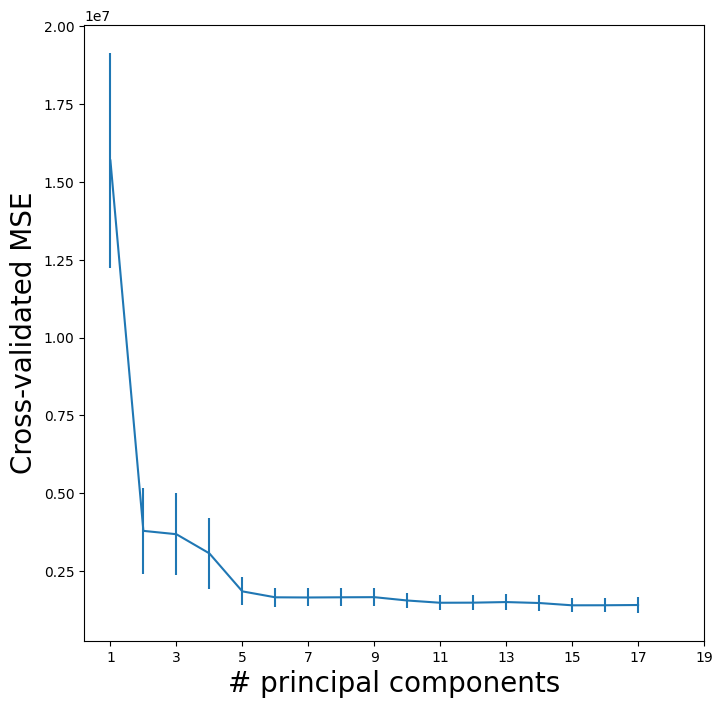

In [ ]:
pcr_fig, ax = plt.subplots(figsize=(8,8))
n_comp = param_grid['pca__n_components']

ax.errorbar(n_comp,
            -grid.cv_results_['mean_test_score'],
            grid.cv_results_['std_test_score'] / np.sqrt(K)) 

ax.axvline(15, c='k', ls= '--')
ax.set_ylabel('Cross-validated MSE', fontsize=20) 
ax.set_xlabel('# principal components', fontsize=20) 
ax.set_xticks(n_comp[::2]);

In [2338]:
pipe.named_steps['pca'].explained_variance_ratio_

array([0.50264858, 0.37760583])

In [2339]:
pca = PCA(n_components=11)
linreg = skl.LinearRegression()

pipe = Pipeline([('pca', pca), 
                ('linreg', linreg)]) 

pipe.fit(X, Y)

test_y_pred = pipe.predict(test_X)
train_y_pred = pipe.predict(X)

train_mse = mean_squared_error(y_true=Y, y_pred=train_y_pred)
test_mse = mean_squared_error(y_true=test_y, y_pred=test_y_pred)
print(f'Train MSE: {train_mse}\tTest MSE: {test_mse}')

Train MSE: 1237114.2267654573	Test MSE: 897233.8061513515


**The M selected by PCA was 15, resulting in a Test MSE of 897233.81. The explained variance ratio for n=1 and n=2, 50.3% and 37.8%, respectively, indicate the proportion of the variance in the dataset that can be explained by these components. This is evident in the decrease of MSE as the number of components increases, as each component explains more variance. At n=15, the decrease in MSE for additional components stops, indicating that 15 components explain the variance in the data.**

In [2340]:
save_model_results('PCA', train_mse, test_mse)

## Part F

it a PLS model on the training set, with M chosen by cross-validation. Report the test error obtained, along with the value of M selected by cross-validation.

In [2341]:
from sklearn.cross_decomposition import PLSRegression

In [2342]:
pls = PLSRegression(n_components=2,
scale=True)
pls.fit(X, Y)

,n_components,2
,scale,True
,max_iter,500
,tol,1e-06
,copy,True


In [2343]:
param_grid = {'n_components':range(1, 20)}
grid = skm.GridSearchCV(pls,
                        param_grid,
                        cv=kfold,
                        scoring='neg_mean_squared_error')
grid.fit(X, Y)

,estimator,PLSRegression()
,param_grid,"{'n_components': range(1, 20)}"
,scoring,'neg_mean_squared_error'
,n_jobs,None
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_components,14


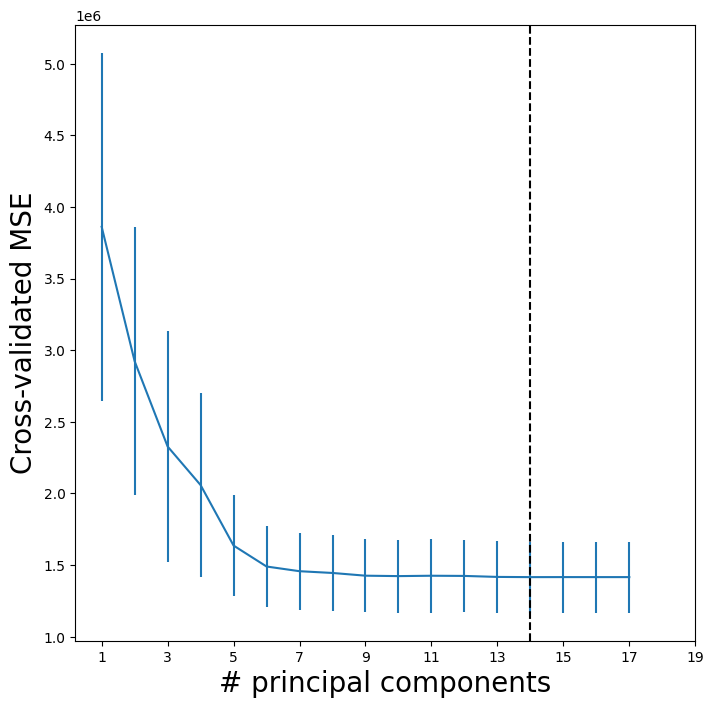

In [2344]:
pls_fig, ax = plt.subplots(figsize=(8,8))
n_comp = param_grid['n_components']

ax.errorbar(n_comp,
            -grid.cv_results_['mean_test_score'],
            grid.cv_results_['std_test_score'] / np.sqrt(K))
 
ax.axvline(grid.best_estimator_.n_components, c='k', ls= '--')
ax.set_ylabel('Cross-validated MSE', fontsize=20) 
ax.set_xlabel('# principal components', fontsize=20) 
ax.set_xticks(n_comp[::2]);

In [2345]:
pls = PLSRegression(n_components=grid.best_estimator_.n_components,
                        scale=True)
pls.fit(X, Y)

test_y_pred = pls.predict(test_X)
train_y_pred = pls.predict(X)

train_mse = mean_squared_error(y_true=Y, y_pred=train_y_pred)
test_mse = mean_squared_error(y_true=test_y, y_pred=test_y_pred)
print(f'Train MSE: {train_mse}\tTest MSE: {test_mse}')

Train MSE: 1119987.1011061163	Test MSE: 878373.1848740944


**The M selected by PLS Regression was 14, resulting in a Test MSE of 878373.18. As the number of components increases, as each component explains more variance, therefore MSE shrinks. At n=14, the decrease in MSE for additional components stops, indicating that 14 components explain the variance in the data.**

In [2346]:
save_model_results('PLS Regression', train_mse, test_mse)

## Part G

Comment on the results obtained. How accurately can we predict the number of college applications received? Is there much difference among the test errors resulting from these five approaches?

**First, let's review the results from all models.**

In [2347]:
for key, val in model_results.items():
    print(f'{key} Results:\nTrain MSE: {val['train_mse']}\t\tTest MSE: {val['test_mse']}\n')

Best Variable Selection Results:
Train MSE: 1126154.5678536464		Test MSE: 897911.5847397848

Ridge Regression Results:
Train MSE: 1119986.0184515722		Test MSE: 878225.8931979352

Lasso Results:
Train MSE: 1134925.6778885475		Test MSE: 859698.6031244679

PCA Results:
Train MSE: 1237114.2267654573		Test MSE: 897233.8061513515

PLS Regression Results:
Train MSE: 1119987.1011061163		Test MSE: 878373.1848740944



**To provide some context for the achieved MSE on each model, compute the naive model MSE.**

In [2348]:
train_mean = Y.mean()
test_y = test_data['Apps']

print(f"Mean of train_y: {train_mean}\n")

baseline_predictions = np.full(shape=len(test_y), fill_value=train_mean)

print("Actual test values (test_y):")
print(np.round(test_y[:5], 2))

print("\nBaseline predictions for the test set:")
print(np.round(baseline_predictions[:5], 2))

baseline_mse = mean_squared_error(test_y, baseline_predictions)

print(f"\nBaseline Test MSE: {baseline_mse}")

Mean of train_y: 3025.4959216965744

Actual test values (test_y):
0     1660
3      417
8     1038
10    1732
11    2652
Name: Apps, dtype: int64

Baseline predictions for the test set:
[3025.5 3025.5 3025.5 3025.5 3025.5]

Baseline Test MSE: 10984265.754850913


**Each of the test MSE values are significantly lower than the baseline test MSE, which is a positive indication that each model has been able to fit to features in the training data.**

**Next, I want to compute the Root Mean Square Error on the test data for each model. The scale of this output can be compared to the mean of test_y.**

In [2349]:
for key, val in model_results.items():
    test_rmse = val['test_mse']**0.5
    percent_error = (test_rmse/test_y.mean())*100
    print(f'{key} Results:\nRMSE: {test_rmse}\tTest Mean: {test_y.mean()}\tPercent Error: {percent_error:.2f}%\n')

Best Variable Selection Results:
RMSE: 947.5819672934816	Test Mean: 2912.4634146341464	Percent Error: 32.54%

Ridge Regression Results:
RMSE: 937.1370727902803	Test Mean: 2912.4634146341464	Percent Error: 32.18%

Lasso Results:
RMSE: 927.1993330047579	Test Mean: 2912.4634146341464	Percent Error: 31.84%

PCA Results:
RMSE: 947.2242639160758	Test Mean: 2912.4634146341464	Percent Error: 32.52%

PLS Regression Results:
RMSE: 937.2156554785533	Test Mean: 2912.4634146341464	Percent Error: 32.18%



**Among each of the methods, there is minimal difference in the error achieved. This points to the data set having outliers in the response variable, or relationships within the predictors that cannot be fit with linear models. To better understand this, let's look at a boxplot of the response variable in both the test and train datasets.**

In [2350]:
import matplotlib.pyplot as plt

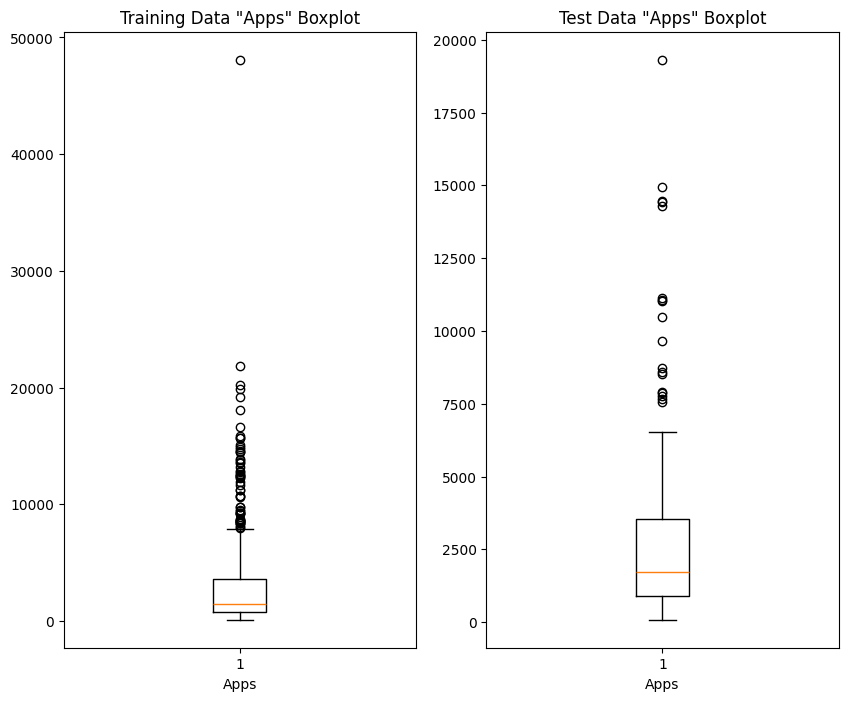

In [2351]:
fig, axes = plt.subplots(1,2,figsize=(10,8))
axes = axes.flatten()

axes[0].boxplot(Y)
axes[0].set_title('Training Data "Apps" Boxplot')
axes[0].set_xlabel('Apps')

axes[1].boxplot(test_y)
axes[1].set_title('Test Data "Apps" Boxplot')
axes[1].set_xlabel('Apps')

plt.show()

**This boxplot supports my hypothesis that there are significant outliers in the training data 'Apps' variable, and fewer in the test set. This helps explain why the test MSE for each model was lower than that of the training data.**

# Problem 11

We will now try to predict per capita crime rate in the Boston dataset.

#### Data Set Information:

A data set containing housing values in 506 suburbs of Boston.

crim: per capita crime rate by town.

zn: proportion of residential land zoned for lots over 25,000 sq.ft.

indus: proportion of non-retail business acres per town.

chas: Charles River dummy variable (= 1 if tract bounds river; 0 otherwise).

nox: nitrogen oxides concentration (parts per 10 million).

rm: average number of rooms per dwelling.

age: proportion of owner-occupied units built prior to 1940.

dis: weighted mean of distances to five Boston employment centres.

rad: index of accessibility to radial highways.

tax: full-value property-tax rate per $10,000.

ptratio: pupil-teacher ratio by town.

lstat: lower status of the population (percent).

medv: median value of owner-occupied homes in $1000s.

In [2352]:
boston = load_data('Boston')

In [2353]:
boston.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  lstat    506 non-null    float64
 12  medv     506 non-null    float64
dtypes: float64(10), int64(3)
memory usage: 51.5 KB


## Part A 

Try out some of the regression methods explored in this chapter, such as best subset selection, the lasso, ridge regression, and PCR. Present and discuss results for the approaches that you consider.

**I am interested in trying the both Forward and Backward Stepwise Selection methods, PLS, Ridge Regression, and the Lasso. The discussion for the results of these approaches can be found at the end of Part A.**

In [2416]:
seed(25)
training_data, test_data = split_data(boston, 80)

print(len(training_data), len(test_data))

404 102


## Both Forward and Backward Stepwise Selection

In [2417]:
design = MS(boston.columns.drop('crim')).fit(boston)
Y = np.array(boston['crim'])
X = design.transform(boston) 
sigma2 = sm.OLS(Y,X).fit().scale
sigma2

np.float64(41.73329329890219)

In [2418]:
neg_Cp = partial(nCp, sigma2)

In [2419]:
strategy = Stepwise.first_peak(design,
                                direction='both',
                                max_terms=len(design.terms))

In [2420]:
boston_Cp = sklearn_selected(sm.OLS,
                            strategy,
                            scoring=neg_Cp)
boston_Cp.fit(boston, Y)
boston_Cp.selected_state_

('lstat', 'medv', 'ptratio', 'rad')

In [2421]:
best_train_X = training_data[list(boston_Cp.selected_state_)]
train_Y = training_data['crim']

best_test_X = test_data[list(boston_Cp.selected_state_)]
test_Y = test_data['crim']

In [2422]:
ols = sm.OLS(train_Y, best_train_X).fit()

test_y_pred = ols.predict(best_test_X)
train_y_pred = ols.predict(best_train_X)

train_mse = mean_squared_error(y_true=train_Y, y_pred=train_y_pred)
test_mse = mean_squared_error(y_true=test_Y, y_pred=test_y_pred)

print(f'Train MSE: {train_mse}\tTest MSE: {test_mse}')

Train MSE: 49.596148895277814	Test MSE: 14.437913974022859


In [2423]:
model_results = {}
save_model_results('Forward and Backward Variable Selection', train_mse, test_mse)

## PLS Regression

In [2424]:
X = training_data.drop('crim', axis = 1)

pls = PLSRegression(n_components=2,
scale=True)
pls.fit(X, train_Y)

,n_components,2
,scale,True
,max_iter,500
,tol,1e-06
,copy,True


In [2425]:
param_grid = {'n_components':range(1, 20)}
grid = skm.GridSearchCV(pls,
                        param_grid,
                        cv=kfold,
                        scoring='neg_mean_squared_error')
grid.fit(X, train_Y)

,estimator,PLSRegression()
,param_grid,"{'n_components': range(1, 20)}"
,scoring,'neg_mean_squared_error'
,n_jobs,None
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_components,11


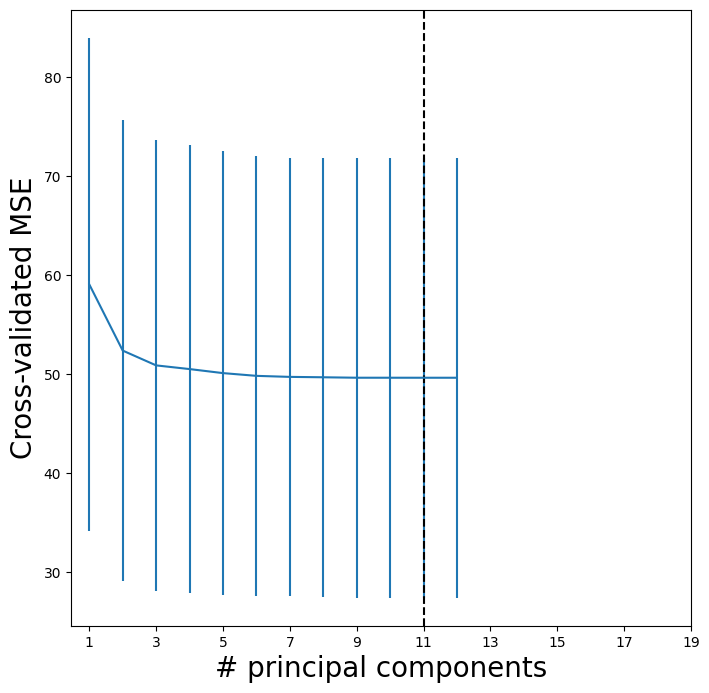

In [2426]:
pls_fig, ax = plt.subplots(figsize=(8,8))
n_comp = param_grid['n_components']

ax.errorbar(n_comp,
            -grid.cv_results_['mean_test_score'],
            grid.cv_results_['std_test_score'] / np.sqrt(K))
 
ax.axvline(grid.best_estimator_.n_components, c='k', ls= '--')
ax.set_ylabel('Cross-validated MSE', fontsize=20) 
ax.set_xlabel('# principal components', fontsize=20) 
ax.set_xticks(n_comp[::2]);

In [2427]:
pls = PLSRegression(n_components=grid.best_estimator_.n_components,
                        scale=True)
pls.fit(X, train_Y)

test_X = test_data.drop('crim', axis = 1)

test_y_pred = pls.predict(test_X)
train_y_pred = pls.predict(X)

train_mse = mean_squared_error(y_true=train_Y, y_pred=train_y_pred)
test_mse = mean_squared_error(y_true=test_Y, y_pred=test_y_pred)
print(f'Train MSE: {train_mse}\tTest MSE: {test_mse}')

Train MSE: 47.20756873083943	Test MSE: 16.0065775042263


In [2428]:
save_model_results('PLS Regression', train_mse, test_mse)

## Ridge Regression

In [2429]:
ridgeCV = skl.ElasticNetCV(alphas=lambdas,
                            l1_ratio=0,
                            cv=kfold)

pipeCV = Pipeline(steps=[('scaler', scaler), 
                         ('ridge', ridgeCV)])

pipeCV.fit(X, train_Y)

,steps,"[('scaler', ...), ('ridge', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,l1_ratio,0
,eps,0.001
,n_alphas,'deprecated'
,alphas,"array([5.1583..., 0.00515836])"


Text(0, 0.5, 'Cross-validated MSE')

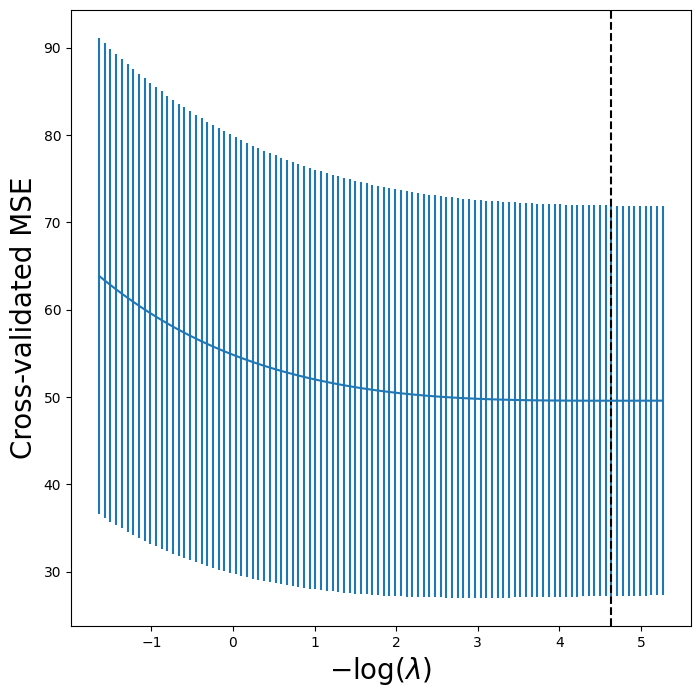

In [2430]:
tuned_ridge = pipeCV.named_steps['ridge']
ridgeCV_fig, ax = plt.subplots(figsize=(8,8))

ax.errorbar(-np.log(lambdas),
            tuned_ridge.mse_path_.mean(1),
            yerr=tuned_ridge.mse_path_.std(1) / np.sqrt(K))

ax.axvline(-np.log(tuned_ridge.alpha_), c='k', ls= '--')
ax.set_xlabel('$-\log(\lambda)$', fontsize=20) 
ax.set_ylabel('Cross-validated MSE', fontsize=20)

In [2431]:
np.min(tuned_ridge.mse_path_.mean(1))

np.float64(49.56586768689628)

In [2432]:
tuned_ridge.coef_

array([ 1.05776889, -0.50513478, -0.15931957, -1.38818991,  0.55860262,
        0.07556125, -2.22841836,  5.57764369, -0.52351093, -0.7417762 ,
        1.10421272, -2.32261537])

**None of the coefficients went to 0 here. Ridge Regression isn't a feature selection method, but this indicates that there is predictive value to each of the variables.**

In [2433]:
test_y_pred = pipeCV.predict(test_X)
train_y_pred = pipeCV.predict(X)

train_mse = mean_squared_error(y_true=train_Y, y_pred=train_y_pred)
test_mse = mean_squared_error(y_true=test_Y, y_pred=test_y_pred)
print(f'Train MSE: {train_mse}\tTest MSE: {test_mse}')

Train MSE: 47.244348637810894	Test MSE: 15.4391764832946


In [2434]:
save_model_results('Ridge Regression', train_mse, test_mse)

## The Lasso

In [2435]:
lassoCV = skl.ElasticNetCV(n_alphas=100,
                            l1_ratio=1,
                            cv=kfold)
pipeCV = Pipeline(steps=[('scaler', scaler), 
('lasso', lassoCV)]) 
pipeCV.fit(X, train_Y)
tuned_lasso = pipeCV.named_steps['lasso']
tuned_lasso.alpha_

np.float64(0.024905410447282526)

In [2436]:
Xs = X - np.array(X.mean(0))[None,:]
X_scale = X.std(0)
Xs = Xs / np.array(X_scale)[None,:]
lambdas = 10**np.linspace(8, -2, 100) / train_Y.std()

In [2437]:
lambdas, soln_array = skl.Lasso.path(Xs,
                                    train_Y,
                                    l1_ratio=1,
                                    n_alphas=100)[:2]

soln_path = pd.DataFrame(soln_array.T,
                            columns=X.columns,
                            index=-np.log(lambdas))

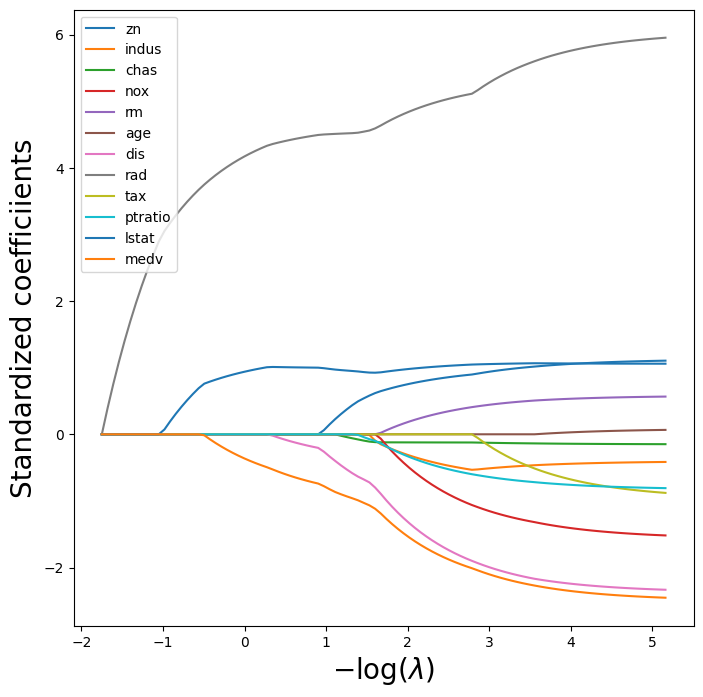

In [2438]:
path_fig, ax = plt.subplots(figsize=(8,8))
soln_path.plot(ax=ax, legend=False)
ax.legend(loc='upper left')
ax.set_xlabel('$-\log(\lambda)$', fontsize=20) 
ax.set_ylabel('Standardized coefficiients', fontsize=20);

In [2439]:
np.min(tuned_lasso.mse_path_.mean(1))

np.float64(49.56614439211658)

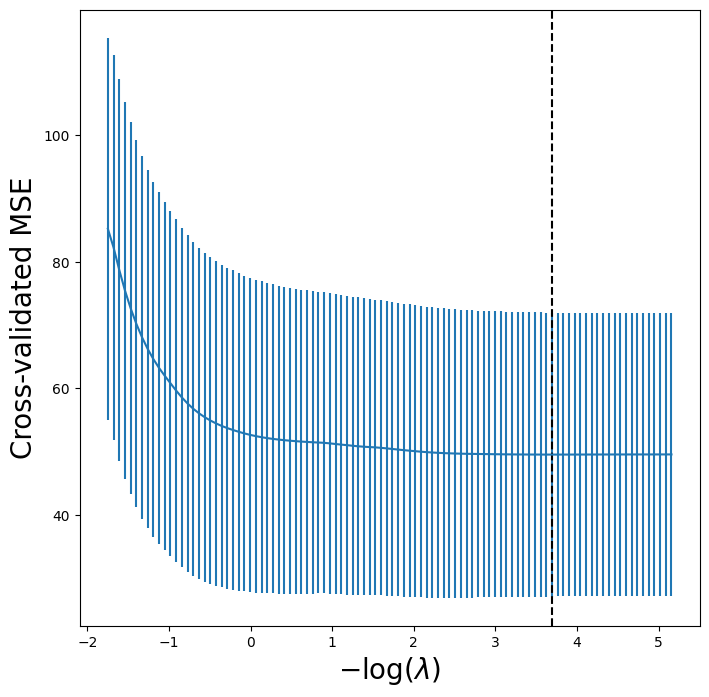

In [2440]:
lassoCV_fig, ax = plt.subplots(figsize=(8,8))

ax.errorbar(-np.log(tuned_lasso.alphas_),
            tuned_lasso.mse_path_.mean(1),
            yerr=tuned_lasso.mse_path_.std(1) / np.sqrt(K))

ax.axvline(-np.log(tuned_lasso.alpha_), c='k', ls= '--')
ax.set_xlabel('$-\log(\lambda)$', fontsize=20) 
ax.set_ylabel('Cross-validated MSE', fontsize=20); 

In [2441]:
tuned_lasso.coef_

array([ 1.03067397, -0.45784359, -0.13855856, -1.35006094,  0.51519875,
        0.01135395, -2.19476986,  5.65225109, -0.57273203, -0.73210633,
        1.06426935, -2.29784546])

**As with the coefficients of the Ridge Regression model, none of the Lasso coefficients went to 0. This further substantiates that every variable has some predictive value in the dataset.**

In [2442]:
test_y_pred = pipeCV.predict(test_X)
train_y_pred = pipeCV.predict(X)

train_mse = mean_squared_error(y_true=train_Y, y_pred=train_y_pred)
test_mse = mean_squared_error(y_true=test_Y, y_pred=test_y_pred)
print(f'Train MSE: {train_mse}\tTest MSE: {test_mse}')

Train MSE: 47.24873554721884	Test MSE: 15.407005891534487


In [2443]:
save_model_results('Lasso', train_mse, test_mse)

In [2444]:
for key, val in model_results.items():
    print(f'{key} Results:\nTrain MSE: {val['train_mse']}\t\tTest MSE: {val['test_mse']}\n')

Forward and Backward Variable Selection Results:
Train MSE: 49.596148895277814		Test MSE: 14.437913974022859

PLS Regression Results:
Train MSE: 47.20756873083943		Test MSE: 16.0065775042263

Ridge Regression Results:
Train MSE: 47.244348637810894		Test MSE: 15.4391764832946

Lasso Results:
Train MSE: 47.24873554721884		Test MSE: 15.407005891534487



In [2445]:
train_mean = train_Y.mean()

print(f"Mean of train_y: {train_mean}\n")

baseline_predictions = np.full(shape=len(test_Y), fill_value=train_mean)

print("Actual test values (test_Y):")
print(np.round(test_Y[:5], 2))

print("\nBaseline predictions for the test set:")
print(np.round(baseline_predictions[:5], 2))

baseline_mse = mean_squared_error(test_Y, baseline_predictions)

print(f"\nBaseline Test MSE: {baseline_mse}")

Mean of train_y: 3.976108094059406

Actual test values (test_Y):
0     0.01
3     0.03
8     0.21
10    0.22
11    0.12
Name: crim, dtype: float64

Baseline predictions for the test set:
[3.98 3.98 3.98 3.98 3.98]

Baseline Test MSE: 26.407773235858503


In [2446]:
for key, val in model_results.items():
    test_rmse = val['test_mse']**0.5
    percent_error = (test_rmse/test_Y.mean())*100
    print(f'{key} Results:\nRMSE: {test_rmse}\tTest Mean: {test_Y.mean()}\tPercent Error: {percent_error:.2f}%\n')

Forward and Backward Variable Selection Results:
RMSE: 3.799725512984176	Test Mean: 2.177404411764706	Percent Error: 174.51%

PLS Regression Results:
RMSE: 4.000822103546508	Test Mean: 2.177404411764706	Percent Error: 183.74%

Ridge Regression Results:
RMSE: 3.929271749738697	Test Mean: 2.177404411764706	Percent Error: 180.46%

Lasso Results:
RMSE: 3.9251759058078513	Test Mean: 2.177404411764706	Percent Error: 180.27%



**Similar to Problem 9, the train MSE is lower than the test MSE for every model. This indicates that the models perform better predicting the test data than the training data, which is unlikely. The relative error for each model is quite high at ~180% of the naive model.**

**To get a better understanding of the response variable and identify the possible source of the error, I will create a boxplot for both test and train data sets.**

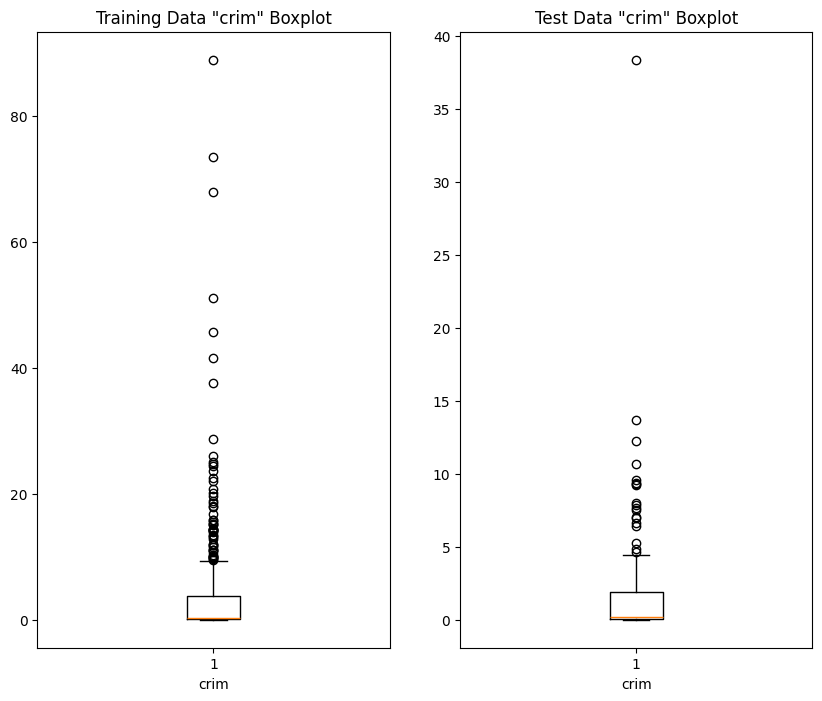

In [2447]:
fig, axes = plt.subplots(1,2,figsize=(10,8))
axes = axes.flatten()

axes[0].boxplot(train_Y)
axes[0].set_title('Training Data "crim" Boxplot')
axes[0].set_xlabel('crim')

axes[1].boxplot(test_Y)
axes[1].set_title('Test Data "crim" Boxplot')
axes[1].set_xlabel('crim')

plt.show()

**As with Problem 9, there are a significant number of outliers in each of the data splits. I suspect this is why the test MSE is lower than the train MSE. The large error in each model is likely a result of the number of outliers in the test set relative to the total number of observations. Let's investigate that theory.**

In [2448]:
len(test_Y)

102

**Now that I know the test dataset contains 102 observations, I can find the number of outliers in the response variable.**

In [2452]:
q1 = np.percentile(test_Y, 25)
q3 = np.percentile(test_Y, 75)


iqr = q3 - q1

lower_bound = q1 - (1.5 * iqr)
upper_bound = q3 + (1.5 * iqr)


outliers = test_Y[(test_Y < lower_bound) | (test_Y > upper_bound)]
outlier_count = len(outliers)

print(f"Q1: {q1}")
print(f"Q3: {q3}")
print(f"IQR: {iqr}")
print(f"Lower Bound: {lower_bound:.2f}")
print(f"Upper Bound: {upper_bound:.2f}\n")
print(f"Count of outliers: {outlier_count}")
print(f"Percent outliers: {(outlier_count/len(test_Y))*100:.2f}")

Q1: 0.0748275
Q3: 1.8817225000000002
IQR: 1.8068950000000001
Lower Bound: -2.64
Upper Bound: 4.59

Count of outliers: 19
Percent outliers: 18.63


**The percentage of outliers in the test response set is about 19%, which is significant. Let's see how this compares to the number of outliers in the train data set.**

In [2453]:
q1 = np.percentile(train_Y, 25)
q3 = np.percentile(train_Y, 75)


iqr = q3 - q1

lower_bound = q1 - (1.5 * iqr)
upper_bound = q3 + (1.5 * iqr)


outliers = train_Y[(train_Y < lower_bound) | (train_Y > upper_bound)]
outlier_count = len(outliers)

print(f"Q1: {q1}")
print(f"Q3: {q3}")
print(f"IQR: {iqr}")
print(f"Lower Bound: {lower_bound:.2f}")
print(f"Upper Bound: {upper_bound:.2f}\n")
print(f"Count of outliers: {outlier_count}")
print(f"Percent outliers: {(outlier_count/len(train_Y))*100:.2f}")

Q1: 0.08254
Q3: 3.840055
IQR: 3.757515
Lower Bound: -5.55
Upper Bound: 9.48

Count of outliers: 56
Percent outliers: 13.86


**The percentage of outliers in the training data set is about 14%, which is about 5% lower than the test data set. This is likely what is driving up the MSE for the test predictions in each model, causing the ~180% error across each model.**

## Part B
Propose a model (or set of models) that seem to perform well on this data set, and justify your answer. Make sure that you are evaluating model performance using validation set error, cross-validation, or some other reasonable alternative, as opposed to using training error.

**Based on validation error, a least squares model with forward and backward stepwise variable selection is the best performing model. This model produced a test MSE of ~14.4. Although this model was the most accurate, it still produced an unsatisfactory percent error on the test set of 174.51%. As stated in the analysis, above, I believe this is a result of the outliers present in the test set.**

## Part C

Does your chosen model involve all of the features in the data set? Why or why not?

In [2454]:
list(boston_Cp.selected_state_)

['lstat', 'medv', 'ptratio', 'rad']

**The chosen model specifically omits features from the data set, as that is the function of stepwise variable selection. The selected features are:**

- **lstat: lower status of the population (percent).**
- **medv: median value of owner-occupied homes in $1000s.**
- **ptratio: pupil-teacher ratio by town.**
- **rad: index of accessibility to radial highways.**

**This combination of predictors produced the lowest *C*<sub>*p*</sub> values across both forward and backward stepwise model testing.**